Testing whether increasing the number of steps in halo mass fixes the bumps in the UVLF

In [12]:
from escripts import eMCMC
from escripts import eplots
from escripts import edata
import zeus21

In [35]:
file_names = ['/Users/eb35267/Desktop/code/home/data/Bouwens2021_fixed.txt', 
              '/Users/eb35267/Desktop/code/home/data/Donnan24_GAL.txt',
             '/Users/eb35267/Desktop/code/home/data/Mcleod_24.txt']
data_labels = ['Bouwens+21', 'Donnan+24', 'McLeod+24']
sorted_data = edata.get_sorted(file_names, data_labels)

In [40]:
params = eMCMC.build_param_data({})

In [51]:
importlib.reload(eMCMC)

<module 'escripts.eMCMC' from '/Users/eb35267/Desktop/code/home/escripts/eMCMC.py'>

In [52]:
my_UVLF_og = eMCMC.UVLF(sorted_data, params)

In [119]:
fully_boosted = eMCMC.UVLF(sorted_data, params, precisionboost = 2)

In [134]:
precisionboost = 1.5
my_UVLF_boosted = eMCMC.UVLF(sorted_data, params, precisionboost = precisionboost)

In [135]:
fit = [0.7, 0, -0.7, 0.41, 13.96, -0.38, -0.59, 0.29, 0, 0.05, 1]

Skipping $z=4.0$
Skipping $z=5.0$
Skipping $z=6.0$
Skipping $z=8.0$
Skipping $z=9.0$
Skipping $z=10.0$
Skipping $z=11.0$
Skipping $z=12.5$
Skipping $z=13.5$
Skipping $z=14.5$


Text(0.5, 1.0, 'Example UVLF')

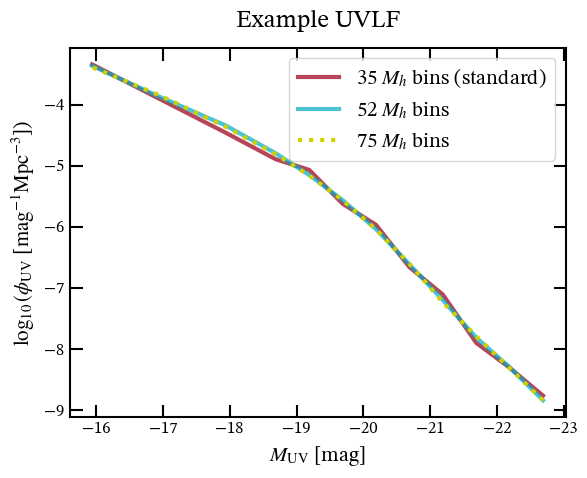

In [137]:
z_plot = [7]
fig, ax = plt.subplots()
plot_xdat, plot_xerr = my_UVLF_og.data[0][2], my_UVLF_og.data[0][5] # Use the lowest redshift MUV centers & bins as the grid to calculate the
                                                                # theoretical UVLF on
i = 0 # Can't use enumerate because we're allowing for the possibility that the user will want to skip certain z bins 
for zbin in my_UVLF_og.sorted_data:

    zdat, zerr = zbin[0][0], zbin[0][1]

    if zdat not in z_plot:
        print(f'Skipping $z={zdat}$')
        continue

    ax.plot(plot_xdat, np.log10(my_UVLF_og.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,fit)), label = r'35 $M_h$ bins (standard)')
    ax.plot(plot_xdat, np.log10(my_UVLF_boosted.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,fit)), 
            label = f'{int(precisionboost * 35)} $M_h$ bins', ls = '-', alpha = 0.7)
    ax.plot(plot_xdat, np.log10(fully_boosted.UVLF_wrapper(zdat,zerr,plot_xdat,plot_xerr,fit)), 
            label = f'75 $M_h$ bins', ls = 'dotted')

ax.invert_xaxis()
ylabel = r'$\log_{10}(\phi_{\rm{UV}}$ [$\rm{mag}^{-1} \rm{Mpc}^{-3}$])'
xlabel = r'$M_{\rm{UV}}$ [mag]'
ax.set_ylabel(ylabel)
ax.set_xlabel(xlabel)
ax.legend()
ax.set_title('Example UVLF')

In [138]:
fig.savefig('/Users/eb35267/Desktop/code/figures/HMF_resolution.png')